In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
class DiffusionUNet(nn.Module):
    class TimeEmbedding(nn.Module):
        def __init__(self,dim=32):
            super().__init__()
            self.dim = dim
            self.mip = nn.Sequential(
                nn.Linear(dim,dim),nn.SiLU(),
                nn.Linear(dim,dim),
            )
        def forward(self,t):
            half = self.dim // 2
            freqs = torch.exp(-np.log(10000) * torch.arange(half,device=t.device) / half)
            args = t.float()[:,None] * freqs[None]
            emb = torch.cat([torch.sin(args),torch.cos(args)],dim=-1)
            return self.mip(emb)
    def _block(self,ic,oc):
        return nn.Sequential(
            nn.Conv2d(ic,oc,3,padding=1),nn.GroupNorm(8,oc),nn.SiLU(),
            nn.Conv2d(oc,oc,3,padding=1),nn.GroupNorm(8,oc),nn.SiLU()
        )
    def __init__(self,in_ch=1,base=32,t_dim=32):
        super().__init__()
        self.t_emb = self.TimeEmbedding(t_dim)
        self.t_proj1 = nn.Linear(t_dim,base * 2)
        self.t_proj2 = nn.Linear(t_dim,base * 4)
        self.t_proj3 = nn.Linear(t_dim,base * 8)
        self.pool = nn.MaxPool2d(2)
        self.enc1 = self._block(in_ch,base)
        self.enc2 = self._block(base,base*2)
        self.enc3 = self._block(base*2,base*4)
        self.bot = self._block(base*4,base*8)
        self.up3 = nn.ConvTranspose2d(base*8,base*4,2,stride=2)
        self.dec3 = self._block(base*8,base*4)
        self.up2 = nn.ConvTranspose2d(base*4,base*2,2,stride=2)
        self.dec2 = self._block(base*4,base*2)
        self.up1 = nn.ConvTranspose2d(base*2,base,2,stride=2)
        self.dec1 = self._block(base*2,base)
        self.out = nn.Conv2d(base,in_ch,1)
    def forward(self,x,t):
        e1 = self.t_emb(t)
        e1p = self.t_proj1(e1)[:,:,None,None]
        e2p = self.t_proj2(e1)[:,:,None,None]
        e3p = self.t_proj3(e1)[:,:,None,None]
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1)) + e1p
        x3 = self.enc3(self.pool(x2)) + e2p
        b = self.bot(self.pool(x3)) + e3p
        d3 = self.dec3(torch.cat([self.up3(b),x3],dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3),x2],dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2),x1],dim=1))
        return self.out(d1)
model = DiffusionUNet()
model.eval()
with torch.no_grad():
    out = model(torch.randn(2,1,32,32),torch.randn(2))
    print(out.shape)

torch.Size([2, 1, 32, 32])


torch.Size([2, 1, 32, 32])


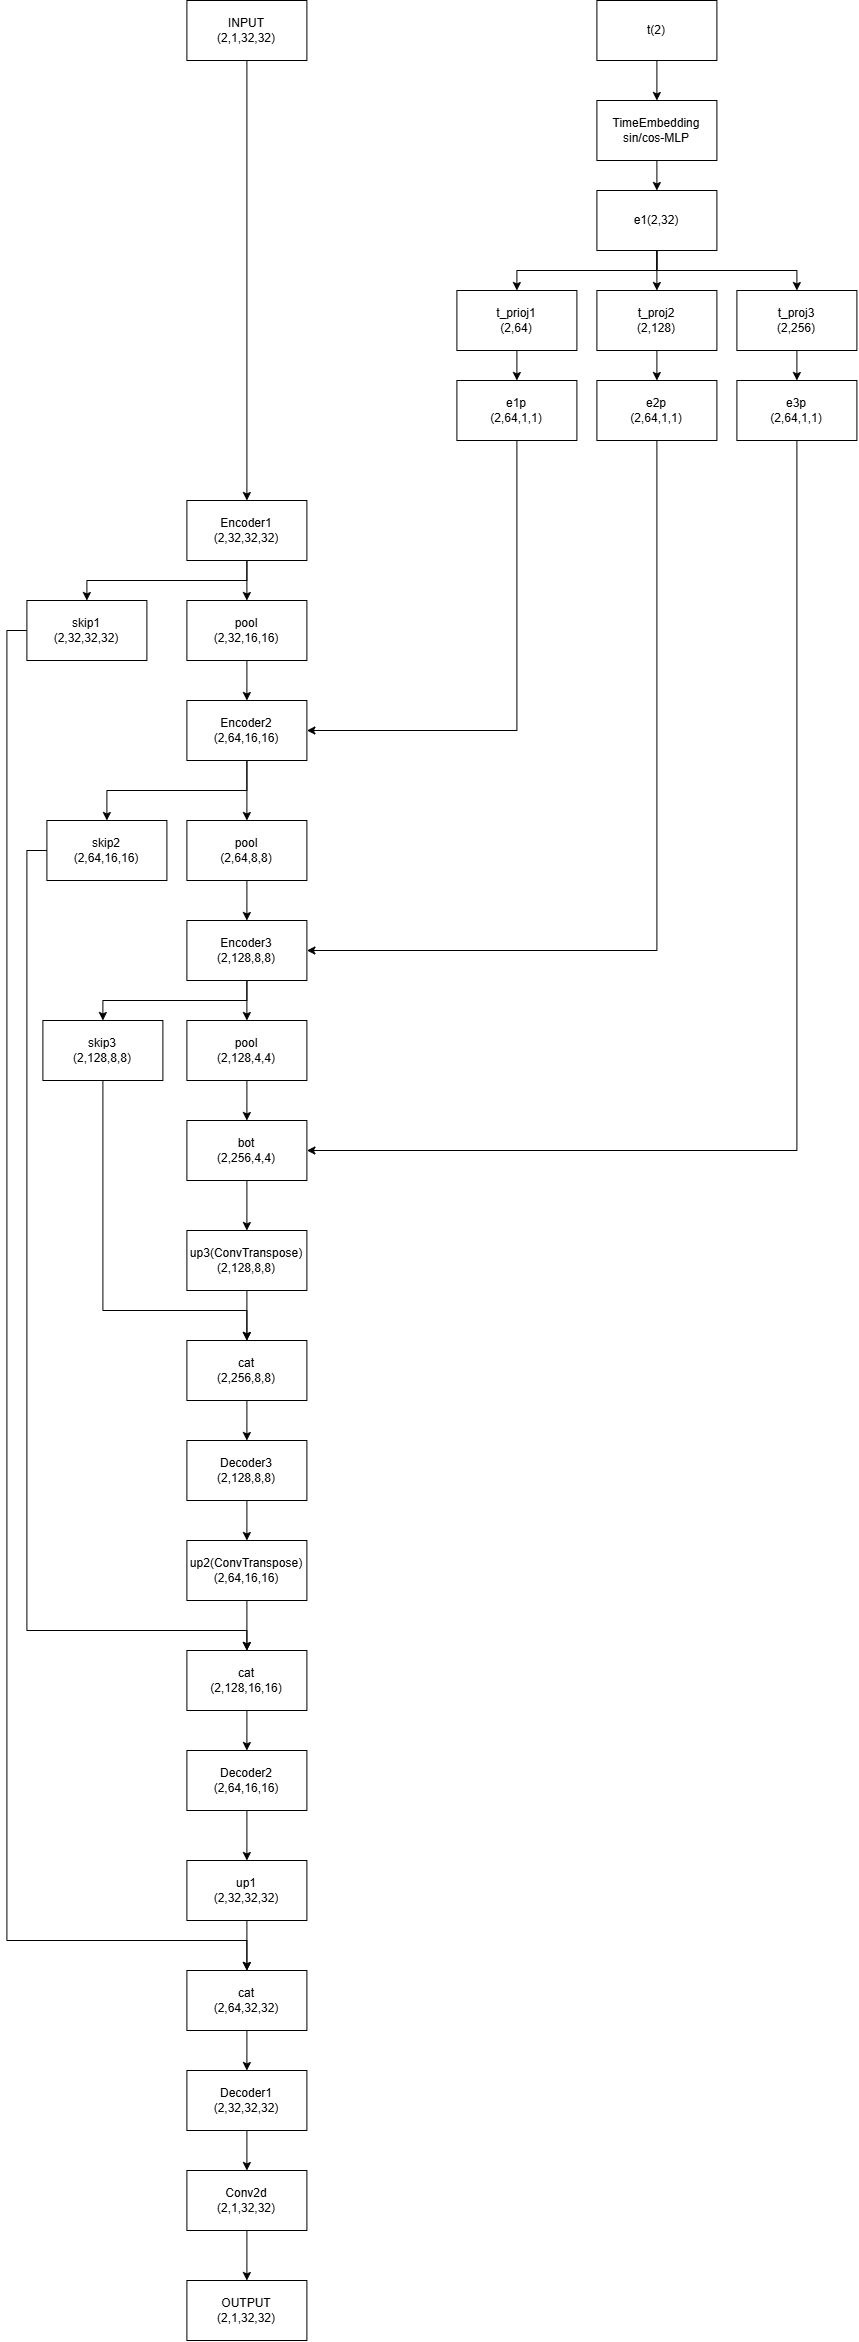

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
class DiffusionUNet(nn.Module):
    class TimeEmbedding(nn.Module):
        def __init__(self,dim=32):
            super().__init__()
            self.dim = dim
            self.mip = nn.Sequential(
                nn.Linear(dim,dim),nn.SiLU(),
                nn.Linear(dim,dim),
            )
        def forward(self,t):
            half = self.dim // 2
            freqs = torch.exp(-np.log(10000) * torch.arange(half,device=t.device) / half)
            args = t.float()[:,None] * freqs[None]
            emb = torch.cat([torch.sin(args),torch.cos(args)],dim=-1)
            return self.mip(emb)
    def _block(self,ic,oc):
        return nn.Sequential(
            nn.Conv2d(ic,oc,3,padding=1),nn.GroupNorm(8,oc),nn.SiLU(),
            nn.Conv2d(oc,oc,3,padding=1),nn.GroupNorm(8,oc),nn.SiLU()
        )
    def __init__(self,in_ch=1,base=32,t_dim=32):
        super().__init__()
        self.t_emb = self.TimeEmbedding(t_dim)
        self.t_proj1 = nn.Linear(t_dim,base*2)
        self.t_proj2 = nn.Linear(t_dim,base*4)
        self.t_proj3 = nn.Linear(t_dim,base*8)
        self.enc1 = self._block(in_ch,base)
        self.enc2 = self._block(base,base*2)
        self.enc3 = self._block(base*2,base*4)
        self.bot = self._block(base*4,base*8)
        self.up3 = nn.ConvTranspose2d(base*8,base*4,2,stride=2)
        self.dec3 = self._block(base*8,base*4)
        self.up2 = nn.ConvTranspose2d(base*4,base*2,2,stride=2)
        self.dec2 = self._block(base*4,base*2)
        self.up1 = nn.ConvTranspose2d(base*2,base,2,stride=2)
        self.dec1 = self._block(base*2,base)
        self.out = nn.Conv2d(base,in_ch,1)
        self.pool = nn.MaxPool2d(2)
    def forward(self,x,t):
        e1 = self.t_emb(t)
        e1p = self.t_proj1(e1)[:,:,None,None]
        e2p = self.t_proj2(e1)[:,:,None,None]
        e3p = self.t_proj3(e1)[:,:,None,None]
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1)) + e1p
        x3 = self.enc3(self.pool(x2)) + e2p
        b = self.bot(self.pool(x3)) + e3p
        d3 = self.dec3(torch.cat([self.up3(b),x3],dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3),x2],dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2),x1],dim=1))
        return self.out(d1)
model = DiffusionUNet()
model.eval()
with torch.no_grad():
    out = model(torch.randn(2,1,32,32),torch.randn(2))
    print(out.shape)
from PIL import Image
import IPython.display as display
img = Image.open('DiffusionUNet .png')
display.display(img)